In [ ]:
#First Unzip the Dataset File
import zipfile
with zipfile.ZipFile('/content/brain_tumor.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import cv2
from glob import glob

In [ ]:
train_path = '/content/Training'
test_path = '/content/Testing'

In [ ]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip= True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip= True,
    fill_mode='nearest'
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=4,
    class_mode='categorical',
    shuffle=True
)

Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


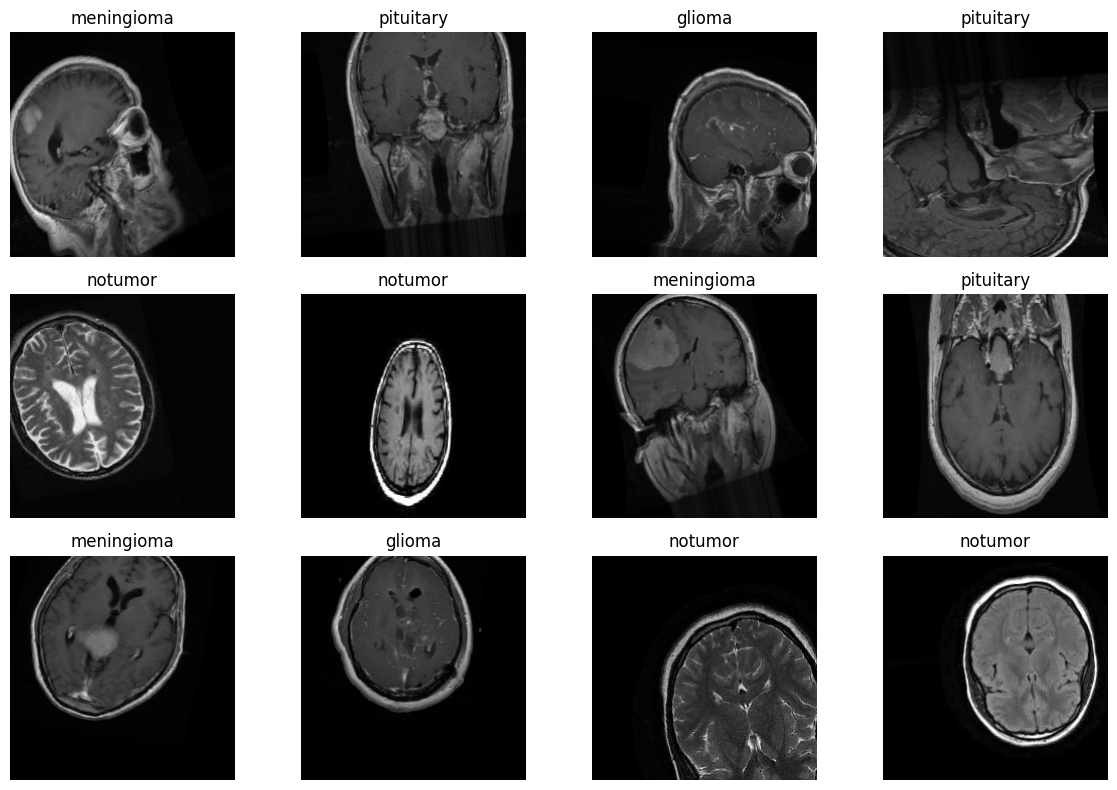

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_images(images, labels, class_names):
    plt.figure(figsize=(12, 8))
    for i in range(12):
        plt.subplot(3, 4, i+1)
        plt.imshow(images[i])
        class_index = np.argmax(labels[i])
        plt.title(class_names[class_index])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

x_train, y_train = next(train_generator)
visualize_images(x_train, y_train, class_names)


In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
IMAGE_SIZE = [224, 224, 3]
base_model = VGG16(input_shape=IMAGE_SIZE, weights='imagenet', include_top=False)

In [ ]:
base_model.trainable = False
inputs = tf.keras.Input(shape=(224, 224, 3))

In [ ]:
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(4, activation = 'softmax')(x)
model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,716,740 (56.14 MB)

 Trainable params: 2,052 (8.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.fit(train_generator, validation_data=test_generator, epochs=50, callbacks=[early_stopping])

Epoch 1/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 109s 587ms/step - accuracy: 0.2469 - loss: 1.4840 - val_accuracy: 0.2815 - val_loss: 1.3646
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 102s 556ms/step - accuracy: 0.3557 - loss: 1.3443 - val_accuracy: 0.4233 - val_loss: 1.3158
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 98s 532ms/step - accuracy: 0.4796 - loss: 1.2963 - val_accuracy: 0.5072 - val_loss: 1.2796
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 144s 541ms/step - accuracy: 0.5634 - loss: 1.2514 - val_accuracy: 0.5690 - val_loss: 1.2410
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 100s 537ms/step - accuracy: 0.6110 - loss: 1.2117 - val_accuracy: 0.5812 - val_loss: 1.2098
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 101s 551ms/step - accuracy: 0.6404 - loss: 1.1716 - val_accuracy: 0.6102 - val_loss: 1.1760
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 99s 540ms/step - accuracy: 0.6472 - loss: 1.1390 - val_accuracy: 0.6308 - val_loss: 1.1470
Epoch 8/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 99s 539ms/step - accuracy: 0.6753 - lo

In [ ]:
# Evaluate the model on test data
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

328/328 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - accuracy: 0.7124 - loss: 0.7554
Test Accuracy: 0.7048


In [ ]:
for layer in model.layers[-10:]:  # Unfreeze the last 10 layers
    layer.trainable = True

# Recompile the model after unfreezing
model.compile(optimizer=Adam(learning_rate=0.00001),  # Lower learning rate for fine-tuning
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Fine-tune the model with early stopping
history_fine = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5,
    callbacks=[early_stopping]
)

Epoch 1/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 209s 877ms/step - accuracy: 0.8144 - loss: 0.5055 - val_accuracy: 0.8307 - val_loss: 0.5151
Epoch 2/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 133s 721ms/step - accuracy: 0.8942 - loss: 0.2927 - val_accuracy: 0.8986 - val_loss: 0.2832
Epoch 3/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 142s 725ms/step - accuracy: 0.9202 - loss: 0.2147 - val_accuracy: 0.9123 - val_loss: 0.2299
Epoch 4/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 140s 712ms/step - accuracy: 0.9234 - loss: 0.2079 - val_accuracy: 0.9268 - val_loss: 0.2100
Epoch 5/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 144s 730ms/step - accuracy: 0.9498 - loss: 0.1480 - val_accuracy: 0.9466 - val_loss: 0.1679


In [ ]:
# Evaluate the model on test data
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

328/328 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.9430 - loss: 0.1892
Test Accuracy: 0.9443


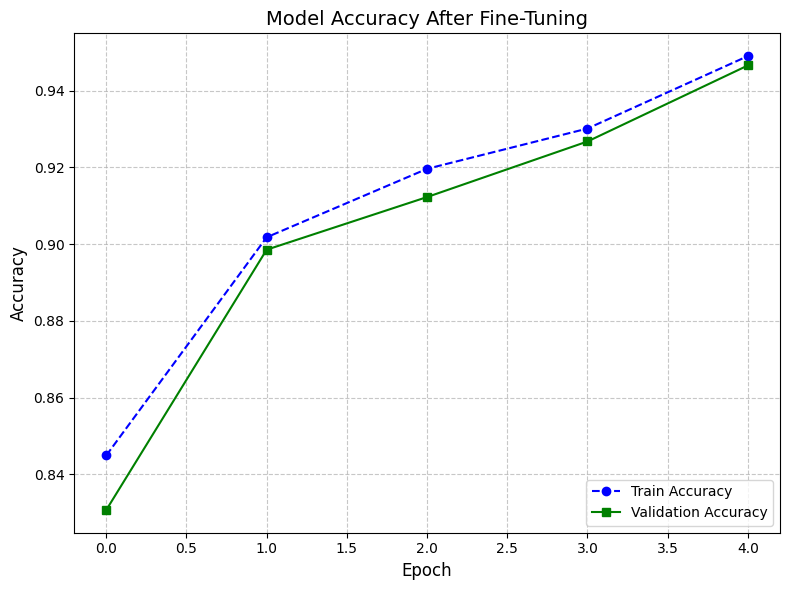

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values for fine-tuning
plt.figure(figsize=(8, 6))
plt.plot(history_fine.history['accuracy'], label='Train Accuracy', color='blue', linestyle='--', marker='o')
plt.plot(history_fine.history['val_accuracy'], label='Validation Accuracy', color='green', linestyle='-', marker='s')
plt.title('Model Accuracy After Fine-Tuning', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


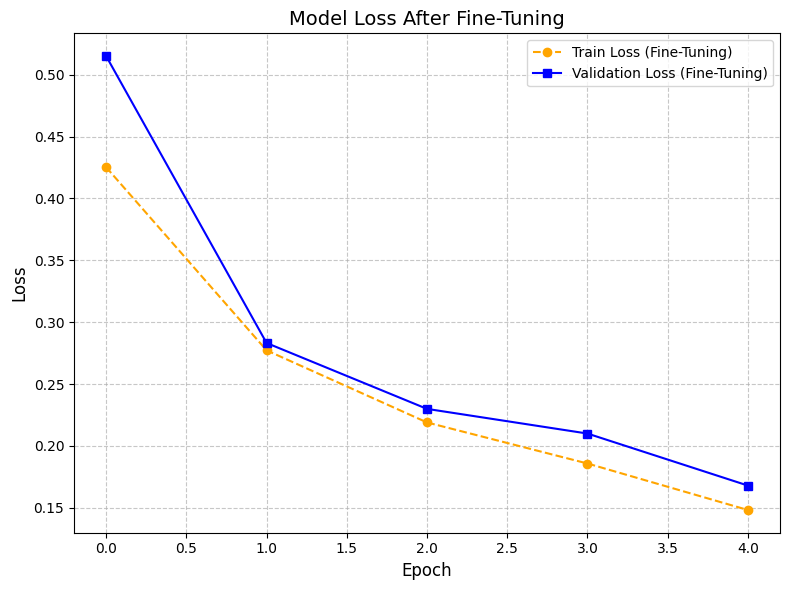

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(history_fine.history['loss'], label='Train Loss (Fine-Tuning)', color='orange', linestyle='--', marker='o')
plt.plot(history_fine.history['val_loss'], label='Validation Loss (Fine-Tuning)', color='blue', linestyle='-', marker='s')
plt.title('Model Loss After Fine-Tuning', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)  # Create the directory if it doesn't exist
os.environ['KAGGLE_CONFIG_DIR'] = '/root/.kaggle'  # Set the correct environment variable path

import shutil
shutil.move('/content/kaggle(5)(1)(4).json', '/root/.kaggle/kaggle.json')  # Move the file to the correct directory

from kaggle.api.kaggle_api_extended import KaggleApi

# Authenticate using the Kaggle API
api = KaggleApi()
api.authenticate()

# Download the dataset
api.dataset_download_files('denizkavi1/brain-tumor', path='.', unzip=True)
api.dataset_download_files('navoneel/brain-mri-images-for-brain-tumor-detection', path='.', unzip=True)


print("Dataset downloaded and extracted!")


Dataset URL: https://www.kaggle.com/datasets/denizkavi1/brain-tumor
Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
Dataset downloaded and extracted!


In [ ]:
path = '/content/brain_tumor_dataset'
# Assuming the data is in 'Training' and 'Testing' folders
# Update this if your dataset has a different structurea
train_path = os.path.join(path, 'Training')
test_path = os.path.join(path, 'Testing')

rootdir = '/content/'
classes_dir = ['yes', 'no']  # total labels

for i in classes_dir:
    if not os.path.exists(rootdir +'/train/' + i):
        os.makedirs(rootdir +'/train/' + i)
    if not os.path.exists(rootdir +'/test/' + i):
        os.makedirs(rootdir +'/test/' + i)

    source = path + '/' + i

    allFileNames = os.listdir(source)

    np.random.shuffle(allFileNames)

    test_ratio = 0.30

    train_FileNames, test_FileNames = np.split(np.array(allFileNames),
                                                          [int(len(allFileNames)* (1 - test_ratio))])

    train_FileNames = [source+'/'+ name for name in train_FileNames.tolist()]
    test_FileNames = [source+'/' + name for name in test_FileNames.tolist()]

    for name in train_FileNames:
      shutil.copy(name, rootdir +'/train/' + i)

    for name in test_FileNames:
      shutil.copy(name, rootdir +'/test/' + i)

In [ ]:
train_path = rootdir + 'train'
test_path = rootdir + 'test'

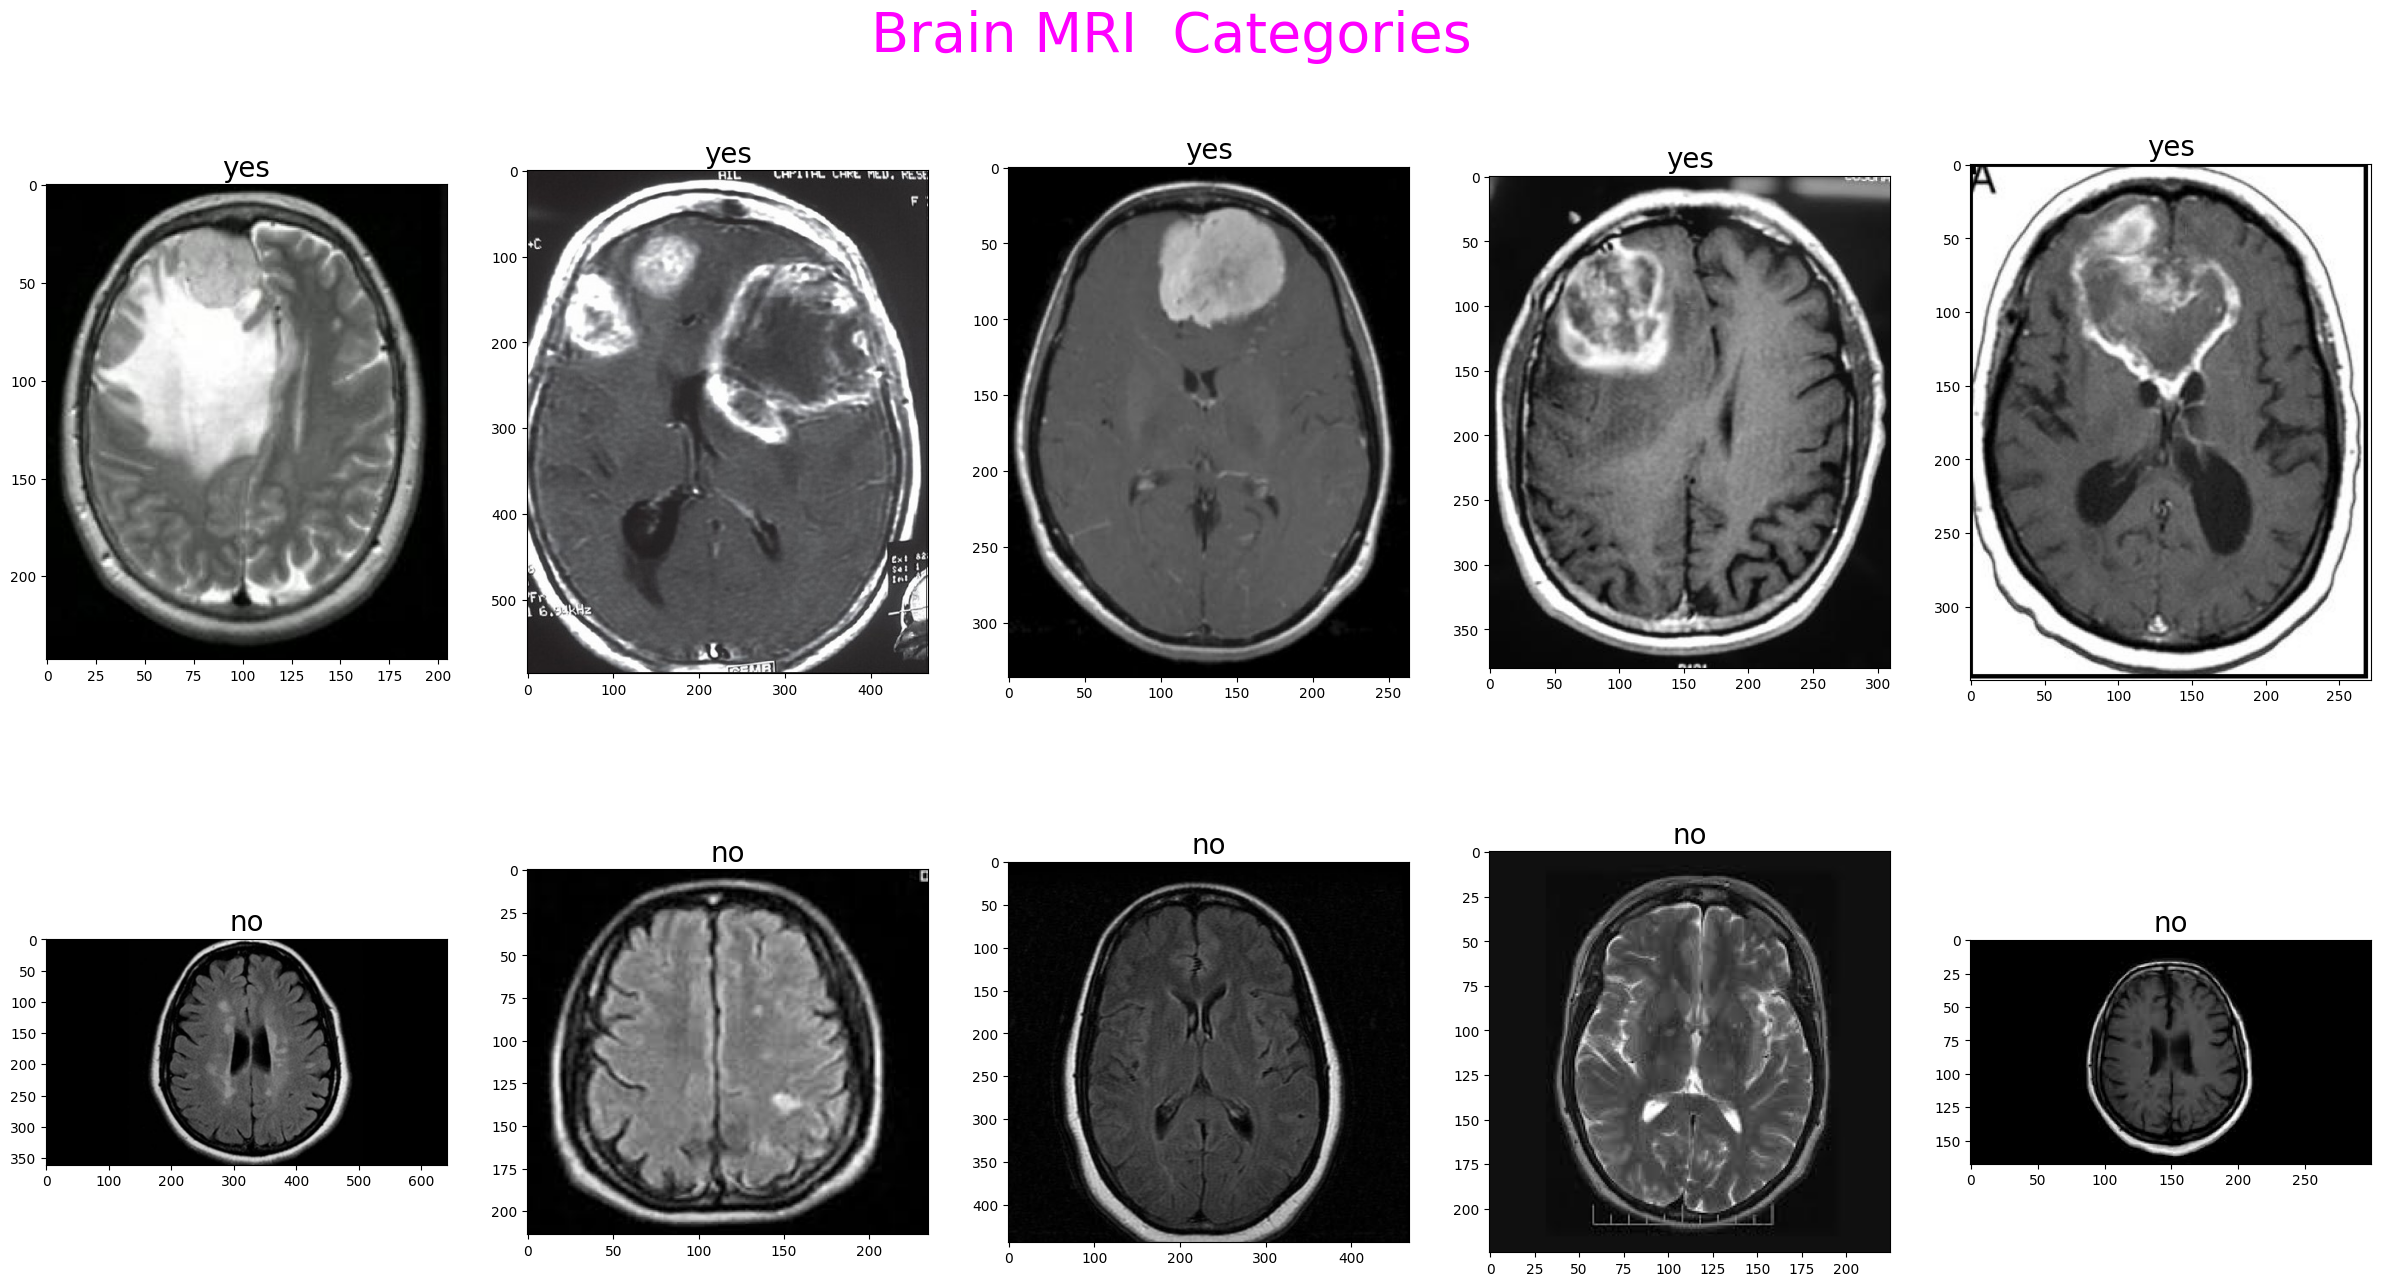

In [ ]:
import matplotlib.image as img
fig, ax = plt.subplots(2,5, figsize=(30,15))
fig.suptitle('Brain MRI  Categories',color='magenta',fontsize=40)
for i in range(2):
    for j in range(5):
        im_src = rootdir +'train/' + classes_dir[i] + '/'
        FileNames = os.listdir(im_src)
        np.random.shuffle(FileNames)
        im_src = str(im_src + FileNames[j])
        imag = img.imread(im_src)
        ax[i, j].imshow(imag)
        ax[i, j].set_title(classes_dir[i], fontsize=20)

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=90,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip= True,
    fill_mode='nearest')

# test Data Augmentation
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=90,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip= True,
    fill_mode='nearest')

In [ ]:
train_set = train_datagen.flow_from_directory(train_path,
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'binary')
test_set = test_datagen.flow_from_directory(test_path,
                                            target_size = (224, 224),
                                            batch_size = 4,
                                            class_mode = 'binary')
no_of_validation_images = len(test_set)
validation_steps = np.ceil(no_of_validation_images)

Found 176 images belonging to 2 classes.
Found 77 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
IMAGE_SIZE = [224, 224, 3]
base_model = VGG16(input_shape=IMAGE_SIZE, weights='imagenet', include_top=False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False
inputs = tf.keras.Input(shape=(224, 224, 3))

In [ ]:
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(1, activation = 'sigmoid')(x)
model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras import optimizers
adam = optimizers.Adam()
model.compile(loss='binary_crossentropy',
              optimizer=adam,
              metrics=['accuracy'])

In [ ]:
model_history=model.fit(
                      train_set,
                      validation_data=test_set,
                      epochs=15,
                     )

Epoch 1/15


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


6/6 ━━━━━━━━━━━━━━━━━━━━ 176s 30s/step - accuracy: 0.5754 - loss: 1.2139 - val_accuracy: 0.5714 - val_loss: 0.9886
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 227s 35s/step - accuracy: 0.6222 - loss: 0.9508 - val_accuracy: 0.6623 - val_loss: 0.9366
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 178s 31s/step - accuracy: 0.6712 - loss: 0.8873 - val_accuracy: 0.6104 - val_loss: 0.9621
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 198s 32s/step - accuracy: 0.6762 - loss: 0.7923 - val_accuracy: 0.6234 - val_loss: 0.8971
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 172s 30s/step - accuracy: 0.6939 - loss: 0.6686 - val_accuracy: 0.6623 - val_loss: 0.8689
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 176s 30s/step - accuracy: 0.6765 - loss: 0.7419 - val_accuracy: 0.5974 - val_loss: 0.7837
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 171s 29s/step - accuracy: 0.7577 - loss: 0.6446 - val_accuracy: 0.6623 - val_loss: 0.6353
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 174s 30s/step - accuracy: 0.7592 - loss: 0.5777 - val_accuracy: 0.7013 - val_loss: 0.6072
Epo

In [ ]:
# Evaluate the model on test data
test_loss, test_acc = model.evaluate(test_set)
print(f"Test Accuracy: {test_acc:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.7894 - loss: 0.6212
Test Accuracy: 0.8312


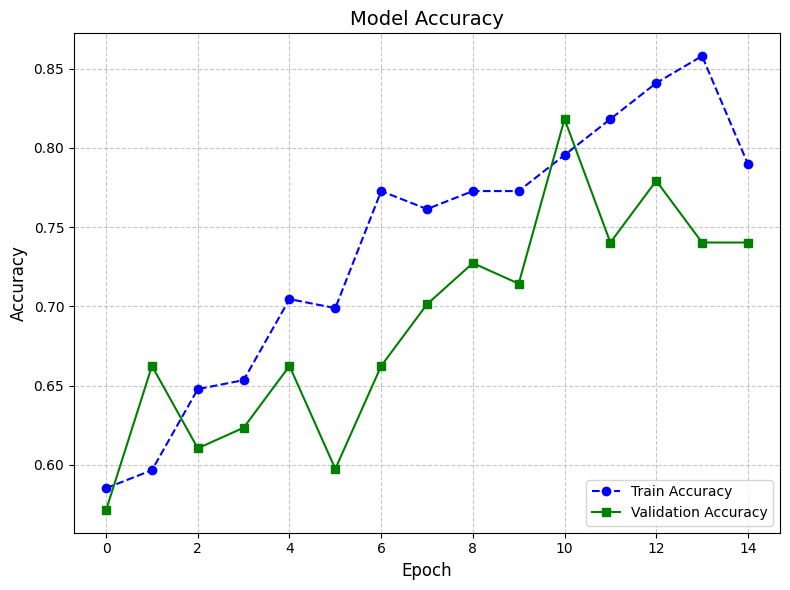

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values for fine-tuning
plt.figure(figsize=(8, 6))
plt.plot(model_history.history['accuracy'], label='Train Accuracy', color='blue', linestyle='--', marker='o')
plt.plot(model_history.history['val_accuracy'], label='Validation Accuracy', color='green', linestyle='-', marker='s')
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


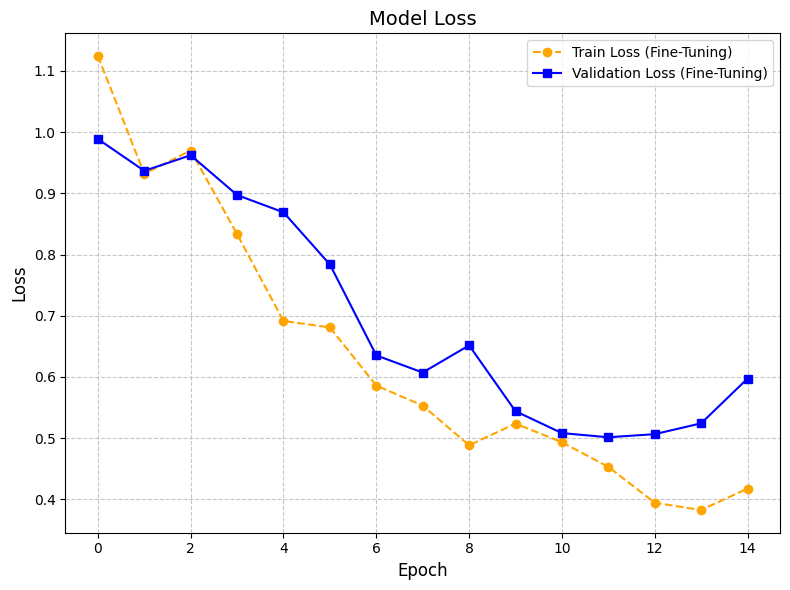

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(model_history.history['loss'], label='Train Loss (Fine-Tuning)', color='orange', linestyle='--', marker='o')
plt.plot(model_history.history['val_loss'], label='Validation Loss (Fine-Tuning)', color='blue', linestyle='-', marker='s')
plt.title('Model Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import os
import shutil
import numpy as np

# Define paths for each class
path_1 = '/content/1'  # Meningioma
path_2 = '/content/2'  # Glioma
path_3 = '/content/3'  # Pituitary tumor

# Root directory for train and test split
rootdir = '/content/brain_tumor_split'
train_dir = os.path.join(rootdir, 'train')
test_dir = os.path.join(rootdir, 'test')

# Create train and test folders for each class
classes = {'1': 'meningioma', '2': 'glioma', '3': 'pituitary_tumor'}
for class_name in classes.values():
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

# Split and copy files
def split_and_copy(source_path, class_name, train_dest, test_dest, test_ratio=0.3):
    all_files = os.listdir(source_path)
    np.random.shuffle(all_files)  # Shuffle the files

    # Split the data into train and test
    train_files, test_files = np.split(np.array(all_files),
                                       [int(len(all_files) * (1 - test_ratio))])

    # Copy train files
    for file in train_files:
        src = os.path.join(source_path, file)
        dest = os.path.join(train_dest, class_name, file)
        shutil.copy(src, dest)

    # Copy test files
    for file in test_files:
        src = os.path.join(source_path, file)
        dest = os.path.join(test_dest, class_name, file)
        shutil.copy(src, dest)

# Apply the function to all classes
split_and_copy(path_1, 'meningioma', train_dir, test_dir)
split_and_copy(path_2, 'glioma', train_dir, test_dir)
split_and_copy(path_3, 'pituitary_tumor', train_dir, test_dir)

print("Train-test split completed successfully!")


Train-test split completed successfully!


In [ ]:
train_path = '/content/brain_tumor_split/train'
test_path = '/content/brain_tumor_split/test'

In [ ]:
class_names = ['glioma', 'meningioma', 'pituitary_tumour']

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip= True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip= True,
    fill_mode='nearest'
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=4,
    class_mode='categorical',
    shuffle=True
)

Found 2144 images belonging to 3 classes.
Found 920 images belonging to 3 classes.


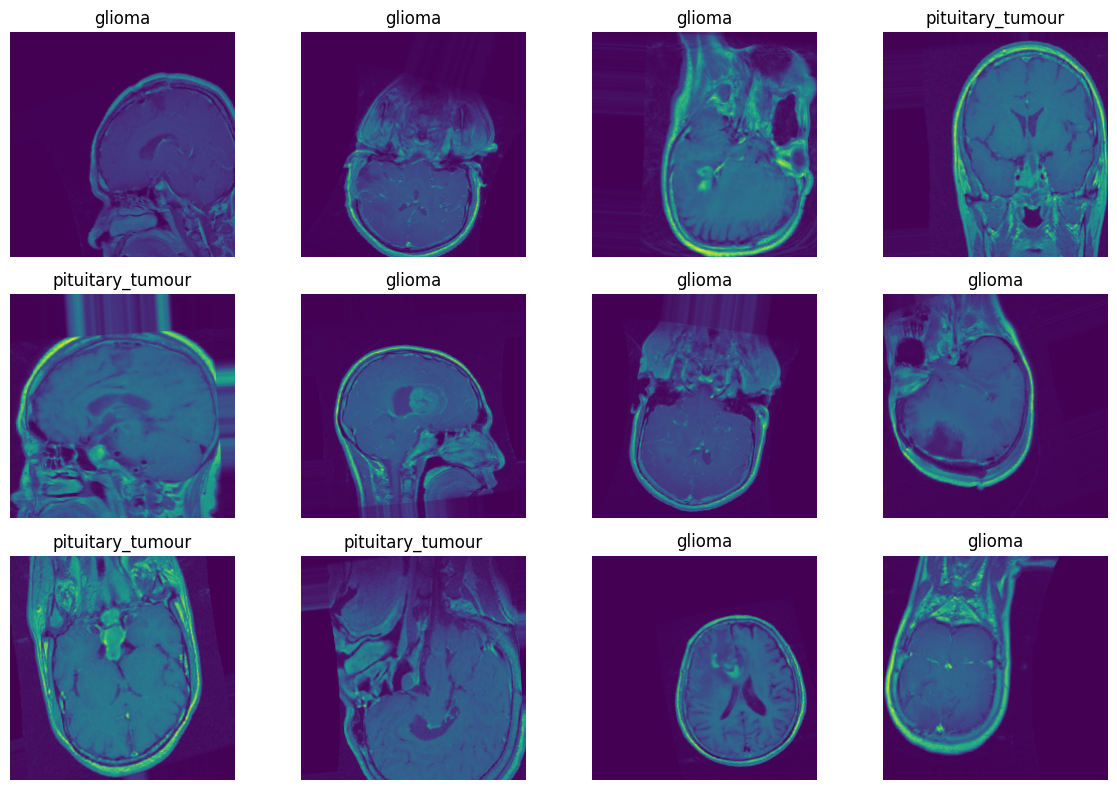

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_images(images, labels, class_names):
    plt.figure(figsize=(12, 8))
    for i in range(12):
        plt.subplot(3, 4, i+1)
        plt.imshow(images[i])
        class_index = np.argmax(labels[i])
        plt.title(class_names[class_index])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

x_train, y_train = next(train_generator)
visualize_images(x_train, y_train, class_names)


In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
IMAGE_SIZE = [224, 224, 3]
base_model = VGG16(input_shape=IMAGE_SIZE, weights='imagenet', include_top=False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
base_model.trainable = False
inputs = tf.keras.Input(shape=(224, 224, 3))

In [ ]:
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(3, activation = 'softmax')(x)
model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 3)                   │           1,539 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,716,227 (56.14 MB)

 Trainable params: 1,539 (6.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.fit(train_generator, validation_data=test_generator, epochs=20, callbacks=[early_stopping])

Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


67/67 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.2304 - loss: 1.2407 - val_accuracy: 0.3109 - val_loss: 1.1148
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.3820 - loss: 1.0959 - val_accuracy: 0.4620 - val_loss: 1.0587
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.4751 - loss: 1.0585 - val_accuracy: 0.4652 - val_loss: 1.0430
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.4726 - loss: 1.0480 - val_accuracy: 0.4652 - val_loss: 1.0353
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.4491 - loss: 1.0375 - val_accuracy: 0.4674 - val_loss: 1.0260
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.4558 - loss: 1.0334 - val_accuracy: 0.4652 - val_loss: 1.0159
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.4620 - loss: 1.0287 - val_accuracy: 0.4696 - val_loss: 1.0134
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.4561 - loss: 1.0158 - val_accuracy: 0.4685 - val_loss: 0.9998
E

In [ ]:
# Evaluate the model on test data
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

230/230 ━━━━━━━━━━━━━━━━━━━━ 25s 107ms/step - accuracy: 0.5883 - loss: 0.9198
Test Accuracy: 0.5837


In [ ]:
for layer in model.layers[-10:]:  # Unfreeze the last 10 layers
    layer.trainable = True

# Recompile the model after unfreezing
model.compile(optimizer=Adam(learning_rate=0.00001),  # Lower learning rate for fine-tuning
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Fine-tune the model with early stopping
history_fine = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5,
    callbacks=[early_stopping]
)

Epoch 1/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.6494 - loss: 0.7899 - val_accuracy: 0.8391 - val_loss: 0.4391
Epoch 2/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.8148 - loss: 0.4381 - val_accuracy: 0.8674 - val_loss: 0.3413
Epoch 3/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8431 - loss: 0.3681 - val_accuracy: 0.8957 - val_loss: 0.2722
Epoch 4/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.8958 - loss: 0.2848 - val_accuracy: 0.9130 - val_loss: 0.2296
Epoch 5/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.8953 - loss: 0.2397 - val_accuracy: 0.9272 - val_loss: 0.2076


In [ ]:
# Evaluate the model on test data
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

230/230 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step - accuracy: 0.9181 - loss: 0.2168
Test Accuracy: 0.9250


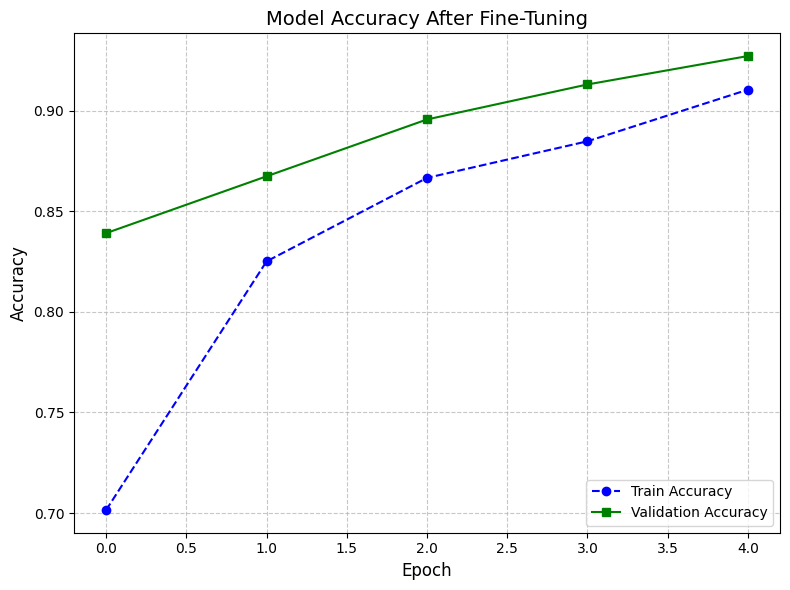

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values for fine-tuning
plt.figure(figsize=(8, 6))
plt.plot(history_fine.history['accuracy'], label='Train Accuracy', color='blue', linestyle='--', marker='o')
plt.plot(history_fine.history['val_accuracy'], label='Validation Accuracy', color='green', linestyle='-', marker='s')
plt.title('Model Accuracy After Fine-Tuning', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


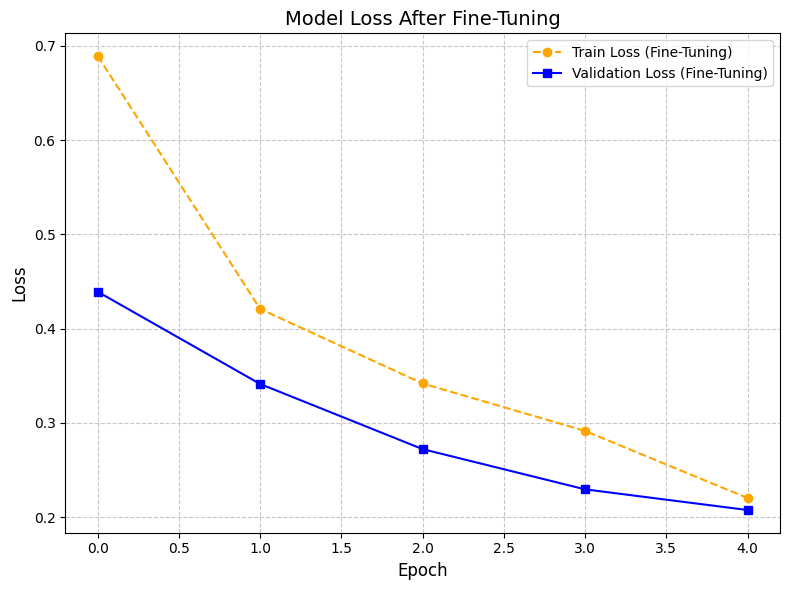

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(history_fine.history['loss'], label='Train Loss (Fine-Tuning)', color='orange', linestyle='--', marker='o')
plt.plot(history_fine.history['val_loss'], label='Validation Loss (Fine-Tuning)', color='blue', linestyle='-', marker='s')
plt.title('Model Loss After Fine-Tuning', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()